In [32]:
import pandas as pd
import matplotlib.pyplot as plt

In [436]:
# Load CSV
df = pd.read_csv("762rpm_constant.csv")

t = df["time_us"]

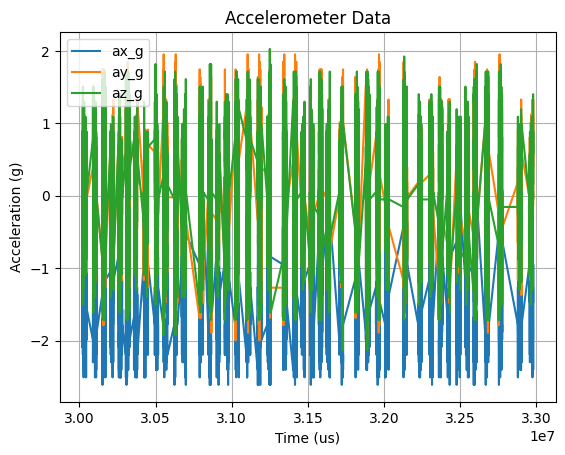

In [437]:
# --- Accelerometer plot ---
plt.figure()
plt.plot(t, df["ax_g"], label="ax_g")
plt.plot(t, df["ay_g"], label="ay_g")
plt.plot(t, df["az_g"], label="az_g")
plt.xlabel("Time (us)")
plt.ylabel("Acceleration (g)")
plt.title("Accelerometer Data")
plt.legend()
plt.grid(True)
plt.show()

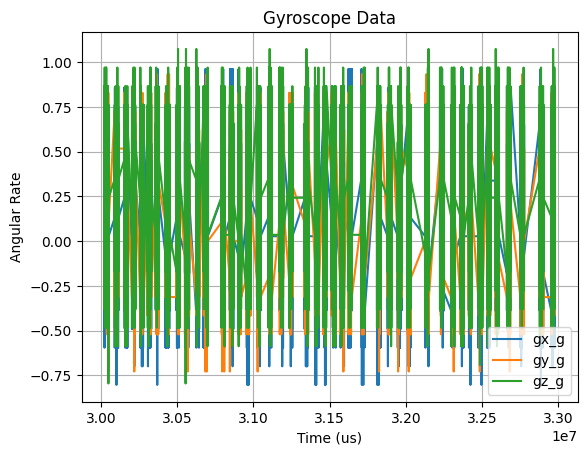

In [438]:
# --- Gyroscope plot ---
plt.figure()
plt.plot(t, df["gx_g"], label="gx_g")
plt.plot(t, df["gy_g"], label="gy_g")
plt.plot(t, df["gz_g"], label="gz_g")
plt.xlabel("Time (us)")
plt.ylabel("Angular Rate")
plt.title("Gyroscope Data")
plt.legend()
plt.grid(True)
plt.show()

In [181]:
import numpy as np
import matplotlib.pyplot as plt

In [439]:
t = df["time_us"].values * 1e-6 # to seconds
x = df["az_g"].values

# dt = np.mean(np.diff(t))
# fs = 1.0 / dt

fs = 4000.0  # Hz
dt = 1.0 / fs

x = x - np.mean(x)

N = len(x)
window = np.hanning(N)

X = np.fft.rfft(x * window)
freq = np.fft.rfftfreq(N, d=dt)

magnitude = np.abs(X) / (np.sum(window) / 2)

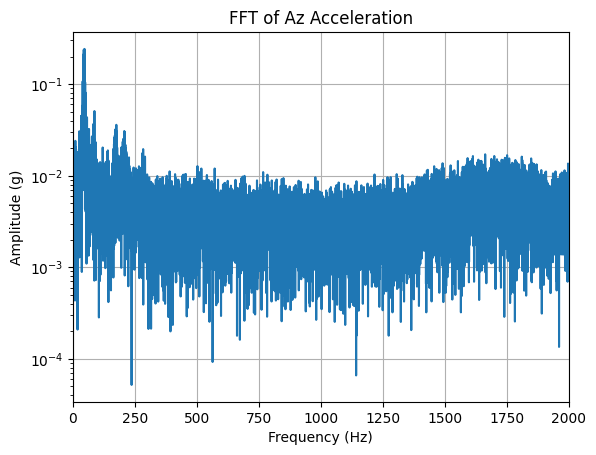

In [440]:
plt.figure()
plt.plot(freq, magnitude)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude (g)")
plt.title("FFT of Az Acceleration")
plt.grid(True)
plt.yscale("log")
plt.xlim(0, fs / 2)
plt.show()

In [90]:
import numpy as np
import matplotlib.pyplot as plt

In [441]:
# Example: use az_raw
t_us = df["time_us"].values
x = df["az_g"].values

In [442]:
# --- Compute sampling frequency ---
# t_s = t_us * 1e-6           # convert to seconds for FFT
# dt = np.mean(np.diff(t_s))
# fs = 1.0 / dt

fs = 4000.0  # Hz
dt = 1.0 / fs

print(f"Estimated sampling rate: {fs:.1f} Hz")

# Remove DC bias
x_dc = x - np.mean(x)

Estimated sampling rate: 4000.0 Hz


In [443]:
# --- FFT calculation ---
N = len(x_dc)
window = np.hanning(N)
X = np.fft.rfft(x_dc * window)
freq = np.fft.rfftfreq(N, d=dt)
magnitude = np.abs(X) / (np.sum(window)/2)

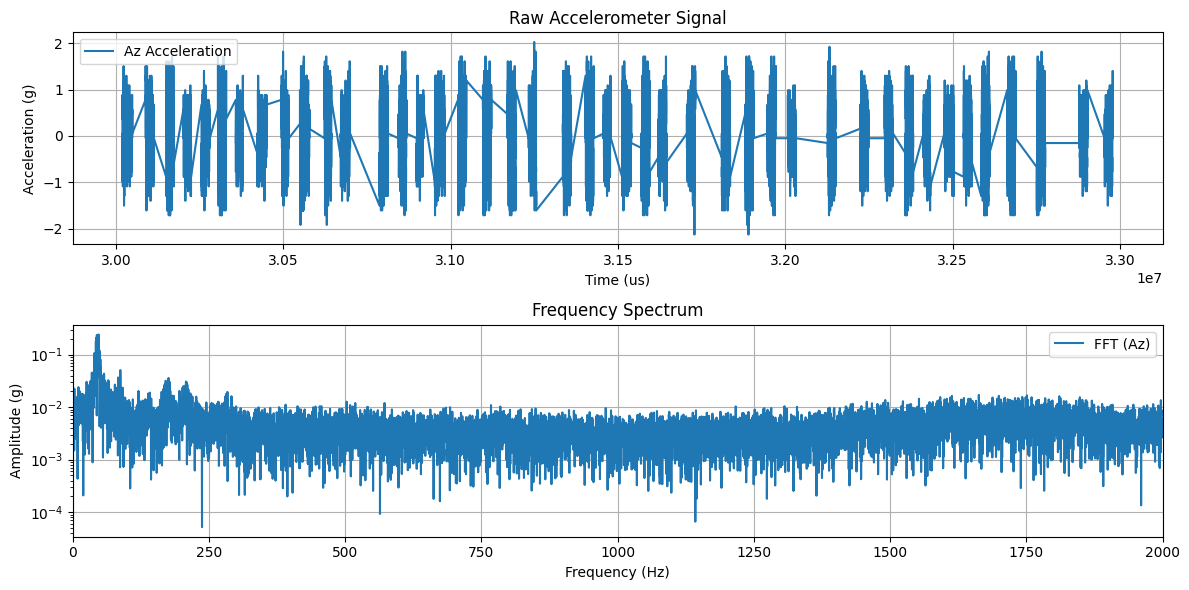

In [444]:
# --- Plotting ---
plt.figure(figsize=(12, 6))

# Top subplot: raw signal in ms
plt.subplot(2, 1, 1)
plt.plot(t_us, x, label="Az Acceleration")
plt.xlabel("Time (us)")
plt.ylabel("Acceleration (g)")
plt.title("Raw Accelerometer Signal")
plt.grid(True)
plt.legend()

# Bottom subplot: FFT in Hz
plt.subplot(2, 1, 2)
plt.plot(freq, magnitude, label="FFT (Az)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude (g)")
plt.title("Frequency Spectrum")
plt.xlim(0, fs/2)       # Nyquist limit
plt.yscale("log")       # optional: log scale for clarity
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()